# CSL / PHOENIX / Neural Sign Actors Exploration & Statistics

This notebook mirrors the local `01_how2sign_subset_exploration_and_stats.ipynb` workflow for the newer SOKE data folders:

- `DATA/SOKE_DATA/CSL-Daily-Fittings`
- `DATA/SOKE_DATA/phoenix_poses`
- `DATA/SOKE_DATA/Neural-Sign-Actors`

It summarizes split sizes, clip/frame counts, pose-file schemas, sample records, and writes reproducible CSV/plot artifacts under `new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/`.


In [1]:

from pathlib import Path
import gzip
import importlib.util
import json
import os
import pickle
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# WSL CUDA reliability guard: keep CUDA stubs visible before importing torch.
if Path('/usr/lib/wsl/lib').exists():
    _wsl_cuda_lib = '/usr/lib/wsl/lib'
    _ld = os.environ.get('LD_LIBRARY_PATH', '')
    _parts = [p for p in _ld.split(':') if p]
    if _wsl_cuda_lib not in _parts:
        os.environ['LD_LIBRARY_PATH'] = f"{_wsl_cuda_lib}:{_ld}" if _ld else _wsl_cuda_lib
        print(f'Prepended WSL CUDA loader path: {_wsl_cuda_lib}')

TORCH_AVAILABLE = importlib.util.find_spec('torch') is not None
if TORCH_AVAILABLE:
    import torch
    print(f'Torch available: {torch.__version__}')
    print(f'CUDA available: {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'CUDA device: {torch.cuda.get_device_name(torch.cuda.current_device())}')
else:
    print('Torch is not installed in this kernel. Torch is only needed for .pt stats or optional rendering.')

plt.style.use('seaborn-v0_8-whitegrid')
RNG_SEED = int(os.environ.get('NEW_DATA_RNG_SEED', '42'))
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)


Torch available: 2.10.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090


In [2]:

def find_project_root() -> Path:
    cur = Path.cwd().resolve()
    for p in [cur, *cur.parents]:
        if (p / 'DATA').exists() and (p / 'new_data').exists():
            return p
    return Path.cwd().resolve()

ROOT = find_project_root()
DATA_DIR = ROOT / 'DATA'
SOKE_DATA = DATA_DIR / 'SOKE_DATA'

CSL_ROOT = SOKE_DATA / 'CSL-Daily-Fittings'
CSL_POSE_ROOT = CSL_ROOT / 'csl-daily_pose' / 'csl-daily_pose'
PHOENIX_ROOT = SOKE_DATA / 'phoenix_poses'
NSA_ROOT = SOKE_DATA / 'Neural-Sign-Actors'

NOTEBOOK_NAME = '01_csl_phoenix_neural_sign_actors_exploration_and_stats'
ARTIFACT_DIR = ROOT / 'new_data' / NOTEBOOK_NAME
PLOT_DIR = ARTIFACT_DIR / 'plots'
for d in [ARTIFACT_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MAX_CLIPS_PER_SPLIT_TEXT = os.environ.get('NEW_DATA_MAX_CLIPS_PER_SPLIT', '').strip()
MAX_CLIPS_PER_SPLIT = int(MAX_CLIPS_PER_SPLIT_TEXT) if MAX_CLIPS_PER_SPLIT_TEXT else None
RUN_RENDER = os.environ.get('NEW_DATA_RUN_RENDER', '0') == '1'
SAMPLE_SIZE = int(os.environ.get('NEW_DATA_SAMPLE_SIZE', '10'))

print('ROOT:', ROOT)
print('SOKE_DATA:', SOKE_DATA, '| exists:', SOKE_DATA.exists())
for label, path in [('CSL_ROOT', CSL_ROOT), ('CSL_POSE_ROOT', CSL_POSE_ROOT), ('PHOENIX_ROOT', PHOENIX_ROOT), ('NSA_ROOT', NSA_ROOT)]:
    print(f'{label}: {path} | exists={path.exists()}')
print('ARTIFACT_DIR:', ARTIFACT_DIR)
print('MAX_CLIPS_PER_SPLIT:', MAX_CLIPS_PER_SPLIT)
print('RUN_RENDER:', RUN_RENDER)


ROOT: /home/cem/tez/exp
SOKE_DATA: /home/cem/tez/exp/DATA/SOKE_DATA | exists: True
CSL_ROOT: /home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fittings | exists=True
CSL_POSE_ROOT: /home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fittings/csl-daily_pose/csl-daily_pose | exists=True
PHOENIX_ROOT: /home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses | exists=True
NSA_ROOT: /home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-Actors | exists=True
ARTIFACT_DIR: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats
MAX_CLIPS_PER_SPLIT: None
RUN_RENDER: False


In [3]:

def _to_numpy(x):
    if TORCH_AVAILABLE:
        import torch
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
    if isinstance(x, np.ndarray):
        return x
    return x


def load_pickle_or_torch(path: Path):
    path = Path(path)
    if TORCH_AVAILABLE:
        try:
            return torch.load(path, map_location='cpu', weights_only=False)
        except Exception:
            pass
    with path.open('rb') as f:
        return pickle.load(f)


def load_gzip_pickle(path: Path):
    with gzip.open(path, 'rb') as f:
        return pickle.load(f)


def count_matching_files(dir_path: Path, suffix: str = '.pkl') -> int:
    try:
        with os.scandir(dir_path) as it:
            return sum(1 for e in it if e.is_file() and e.name.endswith(suffix))
    except FileNotFoundError:
        return 0


def list_clip_dirs(root: Path) -> list[Path]:
    if not root.exists():
        return []
    return sorted([p for p in root.iterdir() if p.is_dir()])


def maybe_limit_dirs(dirs: list[Path], split: str) -> list[Path]:
    if MAX_CLIPS_PER_SPLIT is None or len(dirs) <= MAX_CLIPS_PER_SPLIT:
        return dirs
    rng = random.Random(RNG_SEED + abs(hash(split)) % 100000)
    return sorted(rng.sample(dirs, MAX_CLIPS_PER_SPLIT))


def safe_len(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return 0
    if isinstance(value, (list, tuple, set)):
        return len(value)
    return len(str(value).split())


def describe_frame_schema(path: Path) -> dict:
    obj = load_pickle_or_torch(path)
    row = {'path': str(path), 'type': type(obj).__name__}
    if isinstance(obj, dict):
        row['keys'] = ', '.join(map(str, obj.keys()))
        for k, v in obj.items():
            v = _to_numpy(v)
            shape = tuple(np.shape(v)) if hasattr(v, 'shape') or isinstance(v, (list, tuple)) else None
            dtype = str(getattr(v, 'dtype', '')) if hasattr(v, 'dtype') else ''
            row[f'{k}_shape'] = shape
            row[f'{k}_dtype'] = dtype
    else:
        row['repr'] = repr(obj)[:200]
        row['shape'] = tuple(np.shape(obj)) if hasattr(obj, 'shape') else None
    return row


## CSL-Daily Fittings

The CSL split metadata files are gzip-compressed pickle lists. Each item has keys like `name`, `signer`, `gloss`, `text`, `sign`, and `num_frames`. Pose frames live under `csl-daily_pose/csl-daily_pose/<name>/*.pkl`.


In [4]:

def load_csl_split(split: str) -> pd.DataFrame:
    fp = CSL_ROOT / f'csl_clean.{split}'
    rows = load_gzip_pickle(fp)
    df = pd.DataFrame(rows)
    df['dataset'] = 'CSL-Daily-Fittings'
    df['split'] = 'val' if split == 'val' else split
    df['clip_id'] = df['name'].astype(str)
    df['pose_dir'] = df['clip_id'].map(lambda x: str(CSL_POSE_ROOT / x))
    df['pose_exists'] = df['pose_dir'].map(lambda x: Path(x).exists())
    df['metadata_num_frames'] = pd.to_numeric(df.get('num_frames'), errors='coerce')
    df['frame_pkls'] = [count_matching_files(Path(p), '.pkl') for p in df['pose_dir']]
    df['gloss_tokens'] = df.get('gloss', '').map(safe_len)
    df['text_tokens'] = df.get('text', '').map(safe_len)
    df['sign_tokens'] = df.get('sign', '').map(safe_len)
    df['scan_limited'] = False
    return df

csl_frames = []
for split in ['train', 'val', 'test']:
    df = load_csl_split(split)
    if MAX_CLIPS_PER_SPLIT is not None and len(df) > MAX_CLIPS_PER_SPLIT:
        df = df.sample(MAX_CLIPS_PER_SPLIT, random_state=RNG_SEED).sort_values('clip_id').reset_index(drop=True)
        df['scan_limited'] = True
    csl_frames.append(df)

csl_df = pd.concat(csl_frames, ignore_index=True)
print('CSL rows in this scan:', len(csl_df), '| limited:', bool(csl_df['scan_limited'].any()))
display(csl_df.head())

csl_split_stats = (
    csl_df.groupby(['dataset', 'split'])
    .agg(
        clips=('clip_id', 'nunique'),
        pose_dirs_found=('pose_exists', 'sum'),
        frame_pkls_sum=('frame_pkls', 'sum'),
        metadata_frames_sum=('metadata_num_frames', 'sum'),
        frame_pkls_mean=('frame_pkls', 'mean'),
        frame_pkls_median=('frame_pkls', 'median'),
        frame_pkls_p95=('frame_pkls', lambda s: float(np.percentile(s, 95))),
        frame_pkls_max=('frame_pkls', 'max'),
        signer_count=('signer', 'nunique'),
        gloss_tokens_mean=('gloss_tokens', 'mean'),
        text_tokens_mean=('text_tokens', 'mean'),
    )
    .reset_index()
)
display(csl_split_stats.round(3))


CSL rows in this scan: 20654 | limited: False


,name,signer,gloss,text,sign,num_frames,dataset,split,clip_id,pose_dir,pose_exists,metadata_num_frames,frame_pkls,gloss_tokens,text_tokens,sign_tokens,scan_limited
0,S000000_P0000_T00,0,你们 好,你们好！,[[tensor(0.)]],52,CSL-Daily-Fittings,train,S000000_P0000_T00,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,True,52,52,2,1,1,False
1,S000000_P0004_T00,4,你们 好,你们好！,[[tensor(0.)]],47,CSL-Daily-Fittings,train,S000000_P0004_T00,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,True,47,47,2,1,1,False
2,S000000_P0008_T00,8,你们 好,你们好！,[[tensor(0.)]],58,CSL-Daily-Fittings,train,S000000_P0008_T00,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,True,58,58,2,1,1,False
3,S000001_P0000_T00,0,对不起,对不起！,[[tensor(0.)]],37,CSL-Daily-Fittings,train,S000001_P0000_T00,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,True,37,37,1,1,1,False
4,S000001_P0004_T00,4,对不起,对不起！,[[tensor(0.)]],33,CSL-Daily-Fittings,train,S000001_P0004_T00,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,True,33,33,1,1,1,False


,dataset,split,clips,pose_dirs_found,frame_pkls_sum,metadata_frames_sum,frame_pkls_mean,frame_pkls_median,frame_pkls_p95,frame_pkls_max,signer_count,gloss_tokens_mean,text_tokens_mean
0,CSL-Daily-Fittings,test,1176,1176,149963,150248,127.520,122.0,217.5,340,10,7.655,1.0
1,CSL-Daily-Fittings,train,18401,18401,2179640,2185329,118.452,112.0,206.0,490,10,7.267,1.0
2,CSL-Daily-Fittings,val,1077,1077,131713,131931,122.296,117.0,207.2,339,10,7.589,1.0


## PHOENIX Pose Folders

PHOENIX is organized as `phoenix_poses/<split>/<clip_id>/imagesNNNN.pkl`. Each frame pickle contains SMPL-X pose keys plus 2D projected joints and hand/face boxes.


In [5]:

def scan_phoenix() -> pd.DataFrame:
    rows = []
    for split in ['train', 'dev', 'test']:
        split_root = PHOENIX_ROOT / split
        clip_dirs = maybe_limit_dirs(list_clip_dirs(split_root), f'phoenix_{split}')
        for clip_dir in clip_dirs:
            rows.append({
                'dataset': 'PHOENIX',
                'split': split,
                'clip_id': clip_dir.name,
                'pose_dir': str(clip_dir),
                'pose_exists': clip_dir.exists(),
                'frame_pkls': count_matching_files(clip_dir, '.pkl'),
                'scan_limited': MAX_CLIPS_PER_SPLIT is not None and len(list_clip_dirs(split_root)) > len(clip_dirs),
            })
    return pd.DataFrame(rows)

phoenix_df = scan_phoenix()
print('PHOENIX rows in this scan:', len(phoenix_df), '| limited:', bool(phoenix_df['scan_limited'].any()) if len(phoenix_df) else False)
display(phoenix_df.head())

phoenix_split_stats = (
    phoenix_df.groupby(['dataset', 'split'])
    .agg(
        clips=('clip_id', 'nunique'),
        frame_pkls_sum=('frame_pkls', 'sum'),
        frame_pkls_mean=('frame_pkls', 'mean'),
        frame_pkls_median=('frame_pkls', 'median'),
        frame_pkls_p95=('frame_pkls', lambda s: float(np.percentile(s, 95))),
        frame_pkls_max=('frame_pkls', 'max'),
    )
    .reset_index()
)
display(phoenix_split_stats.round(3))


PHOENIX rows in this scan: 8253 | limited: False


,dataset,split,clip_id,pose_dir,pose_exists,frame_pkls,scan_limited
0,PHOENIX,train,01April_2010_Thursday_heute-6694,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...,True,53,False
1,PHOENIX,train,01April_2010_Thursday_heute-6695,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...,True,90,False
2,PHOENIX,train,01April_2010_Thursday_heute-6696,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...,True,28,False
3,PHOENIX,train,01April_2010_Thursday_heute-6700,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...,True,164,False
4,PHOENIX,train,01April_2010_Thursday_heute-6701,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...,True,57,False


,dataset,split,clips,frame_pkls_sum,frame_pkls_mean,frame_pkls_median,frame_pkls_p95,frame_pkls_max
0,PHOENIX,dev,519,54537,105.081,103.0,180.20,272
1,PHOENIX,test,642,63201,98.444,97.0,176.95,226
2,PHOENIX,train,7092,810045,114.220,109.0,205.00,473


## Neural Sign Actors Pose Folders

Neural Sign Actors is organized as `<split>_poses/poses/<clip_id>/<clip_id>_<frame>_3D.pkl`. Each frame pickle contains the same SMPL-X pose key family as CSL, without PHOENIX's 2D projection/bbox keys.


In [6]:

def scan_neural_sign_actors() -> pd.DataFrame:
    split_map = {'train': 'train_poses', 'val': 'val_poses', 'test': 'test_poses'}
    rows = []
    for split, folder in split_map.items():
        split_root = NSA_ROOT / folder / 'poses'
        all_dirs = list_clip_dirs(split_root)
        clip_dirs = maybe_limit_dirs(all_dirs, f'nsa_{split}')
        for clip_dir in clip_dirs:
            rows.append({
                'dataset': 'Neural-Sign-Actors',
                'split': split,
                'clip_id': clip_dir.name,
                'pose_dir': str(clip_dir),
                'pose_exists': clip_dir.exists(),
                'frame_pkls': count_matching_files(clip_dir, '.pkl'),
                'scan_limited': MAX_CLIPS_PER_SPLIT is not None and len(all_dirs) > len(clip_dirs),
            })
    return pd.DataFrame(rows)

nsa_df = scan_neural_sign_actors()
print('Neural Sign Actors rows in this scan:', len(nsa_df), '| limited:', bool(nsa_df['scan_limited'].any()) if len(nsa_df) else False)
display(nsa_df.head())

nsa_split_stats = (
    nsa_df.groupby(['dataset', 'split'])
    .agg(
        clips=('clip_id', 'nunique'),
        frame_pkls_sum=('frame_pkls', 'sum'),
        frame_pkls_mean=('frame_pkls', 'mean'),
        frame_pkls_median=('frame_pkls', 'median'),
        frame_pkls_p95=('frame_pkls', lambda s: float(np.percentile(s, 95))),
        frame_pkls_max=('frame_pkls', 'max'),
    )
    .reset_index()
)
display(nsa_split_stats.round(3))


Neural Sign Actors rows in this scan: 35007 | limited: False


,dataset,split,clip_id,pose_dir,pose_exists,frame_pkls,scan_limited
0,Neural-Sign-Actors,train,--7E2sU6zP4_10-5-rgb_front,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...,True,365,False
1,Neural-Sign-Actors,train,--7E2sU6zP4_11-5-rgb_front,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...,True,565,False
2,Neural-Sign-Actors,train,--7E2sU6zP4_12-5-rgb_front,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...,True,349,False
3,Neural-Sign-Actors,train,--7E2sU6zP4_13-5-rgb_front,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...,True,144,False
4,Neural-Sign-Actors,train,--7E2sU6zP4_5-5-rgb_front,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...,True,212,False


,dataset,split,clips,frame_pkls_sum,frame_pkls_mean,frame_pkls_median,frame_pkls_p95,frame_pkls_max
0,Neural-Sign-Actors,test,2318,375380,161.941,127.0,422.45,1319
1,Neural-Sign-Actors,train,30965,5034216,162.578,126.0,425.00,2579
2,Neural-Sign-Actors,val,1724,273119,158.422,124.0,395.85,1761


## Combined Split Statistics

In [7]:

common_cols = ['dataset', 'split', 'clip_id', 'pose_dir', 'pose_exists', 'frame_pkls', 'scan_limited']
combined_df = pd.concat([
    csl_df[common_cols + ['metadata_num_frames', 'gloss_tokens', 'text_tokens', 'signer']].rename(columns={'metadata_num_frames': 'metadata_frames'}),
    phoenix_df[common_cols].assign(metadata_frames=np.nan, gloss_tokens=np.nan, text_tokens=np.nan, signer=np.nan),
    nsa_df[common_cols].assign(metadata_frames=np.nan, gloss_tokens=np.nan, text_tokens=np.nan, signer=np.nan),
], ignore_index=True)

combined_stats = (
    combined_df.groupby(['dataset', 'split'])
    .agg(
        clips=('clip_id', 'nunique'),
        pose_dirs_found=('pose_exists', 'sum'),
        frame_pkls_sum=('frame_pkls', 'sum'),
        frame_pkls_mean=('frame_pkls', 'mean'),
        frame_pkls_median=('frame_pkls', 'median'),
        frame_pkls_p95=('frame_pkls', lambda s: float(np.percentile(s, 95))),
        frame_pkls_max=('frame_pkls', 'max'),
        scan_limited=('scan_limited', 'max'),
    )
    .reset_index()
)

display(combined_stats.round(3))

summary_csv = ARTIFACT_DIR / 'combined_split_stats.csv'
clip_index_csv = ARTIFACT_DIR / 'combined_clip_index.csv'
combined_stats.to_csv(summary_csv, index=False)
combined_df.to_csv(clip_index_csv, index=False)
print('Wrote:', summary_csv)
print('Wrote:', clip_index_csv)


,dataset,split,clips,pose_dirs_found,frame_pkls_sum,frame_pkls_mean,frame_pkls_median,frame_pkls_p95,frame_pkls_max,scan_limited
0,CSL-Daily-Fittings,test,1176,1176,149963,127.520,122.0,217.50,340,False
1,CSL-Daily-Fittings,train,18401,18401,2179640,118.452,112.0,206.00,490,False
2,CSL-Daily-Fittings,val,1077,1077,131713,122.296,117.0,207.20,339,False
3,Neural-Sign-Actors,test,2318,2318,375380,161.941,127.0,422.45,1319,False
4,Neural-Sign-Actors,train,30965,30965,5034216,162.578,126.0,425.00,2579,False
5,Neural-Sign-Actors,val,1724,1724,273119,158.422,124.0,395.85,1761,False
6,PHOENIX,dev,519,519,54537,105.081,103.0,180.20,272,False
7,PHOENIX,test,642,642,63201,98.444,97.0,176.95,226,False
8,PHOENIX,train,7092,7092,810045,114.220,109.0,205.00,473,False


Wrote: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/combined_split_stats.csv
Wrote: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/combined_clip_index.csv


Wrote: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/plots/frame_count_stats.png


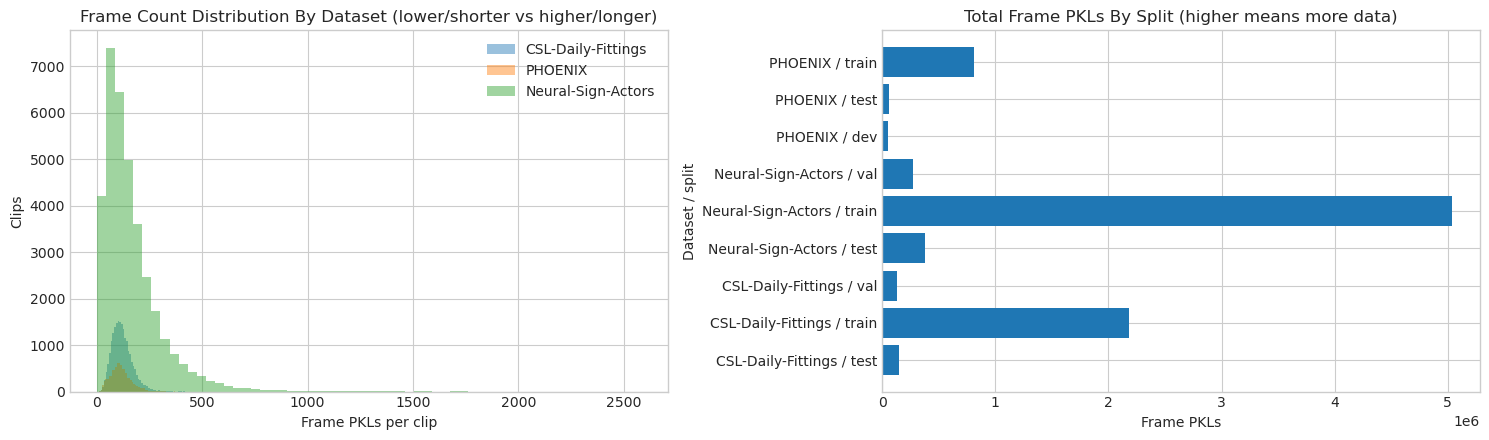

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

plot_df = combined_df[combined_df['frame_pkls'] > 0].copy()
for dataset in plot_df['dataset'].dropna().unique():
    vals = plot_df.loc[plot_df['dataset'] == dataset, 'frame_pkls'].values
    axes[0].hist(vals, bins=60, alpha=0.45, label=dataset)
axes[0].set_title('Frame Count Distribution By Dataset (lower/shorter vs higher/longer)')
axes[0].set_xlabel('Frame PKLs per clip')
axes[0].set_ylabel('Clips')
axes[0].legend()

bar_df = combined_stats.copy()
bar_df['label'] = bar_df['dataset'] + ' / ' + bar_df['split']
axes[1].barh(bar_df['label'], bar_df['frame_pkls_sum'])
axes[1].set_title('Total Frame PKLs By Split (higher means more data)')
axes[1].set_xlabel('Frame PKLs')
axes[1].set_ylabel('Dataset / split')

fig.tight_layout()
plot_path = PLOT_DIR / 'frame_count_stats.png'
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
print('Wrote:', plot_path)
plt.show()


## Random Sample Records And Pose Schemas

In [9]:

sample_rows = []
schema_rows = []

for dataset, df in [('CSL-Daily-Fittings', csl_df), ('PHOENIX', phoenix_df), ('Neural-Sign-Actors', nsa_df)]:
    if len(df) == 0:
        continue
    n = min(SAMPLE_SIZE, len(df))
    sample_df = df.sample(n, random_state=RNG_SEED).copy().reset_index(drop=True)
    for _, row in sample_df.iterrows():
        pose_dir = Path(row['pose_dir'])
        frame_files = sorted(pose_dir.glob('*.pkl'))
        first_frame = frame_files[0] if frame_files else None
        sample_rows.append({
            'dataset': dataset,
            'split': row.get('split'),
            'clip_id': row.get('clip_id'),
            'frame_pkls': int(row.get('frame_pkls', 0)),
            'pose_dir': str(pose_dir),
            'first_frame_pkl': str(first_frame) if first_frame else '',
        })
        if first_frame is not None:
            try:
                schema = describe_frame_schema(first_frame)
                schema['dataset'] = dataset
                schema['split'] = row.get('split')
                schema['clip_id'] = row.get('clip_id')
                schema_rows.append(schema)
            except Exception as e:
                warnings.warn(f'Failed schema load for {first_frame}: {e}')

sample_df = pd.DataFrame(sample_rows)
schema_df = pd.DataFrame(schema_rows)

display(sample_df)
display(schema_df)

sample_csv = ARTIFACT_DIR / 'random_sample_records.csv'
schema_csv = ARTIFACT_DIR / 'sample_pose_schema.csv'
sample_df.to_csv(sample_csv, index=False)
schema_df.to_csv(schema_csv, index=False)
print('Wrote:', sample_csv)
print('Wrote:', schema_csv)


,dataset,split,clip_id,frame_pkls,pose_dir,first_frame_pkl
0,CSL-Daily-Fittings,train,S000885_P0004_T00,148,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
1,CSL-Daily-Fittings,train,S003456_P0000_T00,122,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
2,CSL-Daily-Fittings,train,S000121_P0008_T00,228,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
3,CSL-Daily-Fittings,train,S005099_P0009_T00,37,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
4,CSL-Daily-Fittings,train,S005468_P0006_T00,64,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
5,CSL-Daily-Fittings,val,S003206_P0002_T00,80,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
6,CSL-Daily-Fittings,train,S001262_P0008_T00,134,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
7,CSL-Daily-Fittings,train,S001226_P0004_T00,117,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
8,CSL-Daily-Fittings,train,S001312_P0000_T00,133,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
9,CSL-Daily-Fittings,train,S001939_P0004_T00,183,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...


,path,type,keys,smplx_root_pose_shape,smplx_root_pose_dtype,smplx_body_pose_shape,smplx_body_pose_dtype,smplx_lhand_pose_shape,smplx_lhand_pose_dtype,smplx_rhand_pose_shape,...,split,clip_id,smplx_joint_proj_shape,smplx_joint_proj_dtype,lhand_bbox_shape,lhand_bbox_dtype,rhand_bbox_shape,rhand_bbox_dtype,face_bbox_shape,face_bbox_dtype
0,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S000885_P0004_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S003456_P0000_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S000121_P0008_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S005099_P0009_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S005468_P0006_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,val,S003206_P0002_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S001262_P0008_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S001226_P0004_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S001312_P0000_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S001939_P0004_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Wrote: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/random_sample_records.csv
Wrote: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/sample_pose_schema.csv


## CSL Text / Gloss Statistics

,split,clips,signers,gloss_tokens_mean,gloss_tokens_median,gloss_tokens_p95,text_tokens_mean,text_tokens_median,sign_tokens_mean
0,test,1176,10,7.655,7.0,12.0,1.0,1.0,1.0
1,train,18401,10,7.267,7.0,12.0,1.0,1.0,1.0
2,val,1077,10,7.589,7.0,12.0,1.0,1.0,1.0


Wrote: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/plots/csl_text_gloss_distributions.png


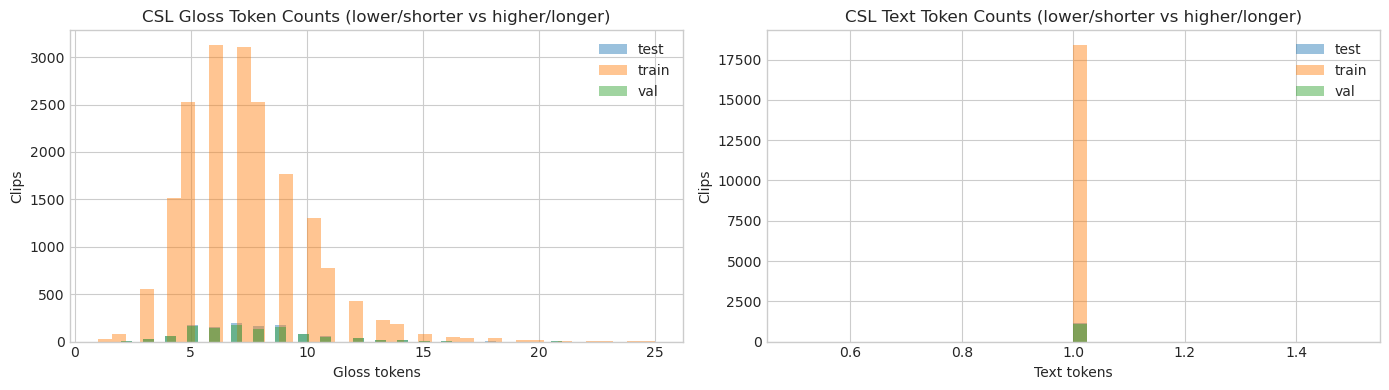

In [10]:

if len(csl_df):
    csl_text_stats = (
        csl_df.groupby('split')
        .agg(
            clips=('clip_id', 'nunique'),
            signers=('signer', 'nunique'),
            gloss_tokens_mean=('gloss_tokens', 'mean'),
            gloss_tokens_median=('gloss_tokens', 'median'),
            gloss_tokens_p95=('gloss_tokens', lambda s: float(np.percentile(s, 95))),
            text_tokens_mean=('text_tokens', 'mean'),
            text_tokens_median=('text_tokens', 'median'),
            sign_tokens_mean=('sign_tokens', 'mean'),
        )
        .reset_index()
    )
    display(csl_text_stats.round(3))
    csl_text_stats.to_csv(ARTIFACT_DIR / 'csl_text_gloss_stats.csv', index=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for split, df in csl_df.groupby('split'):
        axes[0].hist(df['gloss_tokens'], bins=40, alpha=0.45, label=split)
        axes[1].hist(df['text_tokens'], bins=40, alpha=0.45, label=split)
    axes[0].set_title('CSL Gloss Token Counts (lower/shorter vs higher/longer)')
    axes[0].set_xlabel('Gloss tokens')
    axes[0].set_ylabel('Clips')
    axes[0].legend()
    axes[1].set_title('CSL Text Token Counts (lower/shorter vs higher/longer)')
    axes[1].set_xlabel('Text tokens')
    axes[1].set_ylabel('Clips')
    axes[1].legend()
    fig.tight_layout()
    out = PLOT_DIR / 'csl_text_gloss_distributions.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print('Wrote:', out)
    plt.show()


## Optional Mesh-Only Render Smoke Test

This section is disabled by default because these SOKE_DATA folders contain pose frames but not local RGB clips in the same layout as How2Sign. Enable with `NEW_DATA_RUN_RENDER=1` to render one mesh-only clip per dataset when `smplx_gif_renderer.py`, body models, and CUDA are available.


In [11]:

def stack_smplx_frames(frame_files: list[Path]) -> np.ndarray:
    rows = []
    for fp in frame_files:
        obj = load_pickle_or_torch(fp)
        if not isinstance(obj, dict):
            continue
        rows.append(np.concatenate([
            np.asarray(obj['smplx_root_pose'], dtype=np.float32).reshape(-1),
            np.asarray(obj['smplx_body_pose'], dtype=np.float32).reshape(-1),
            np.asarray(obj['smplx_lhand_pose'], dtype=np.float32).reshape(-1),
            np.asarray(obj['smplx_rhand_pose'], dtype=np.float32).reshape(-1),
            np.asarray(obj['smplx_jaw_pose'], dtype=np.float32).reshape(-1),
            np.asarray(obj['smplx_shape'], dtype=np.float32).reshape(-1),
            np.asarray(obj.get('smplx_expr', np.zeros(10, dtype=np.float32)), dtype=np.float32).reshape(-1),
            np.asarray(obj['cam_trans'], dtype=np.float32).reshape(-1),
        ]))
    if not rows:
        raise RuntimeError('No SMPL-X frames could be stacked.')
    return np.stack(rows, axis=0).astype(np.float32)

if RUN_RENDER:
    import torch
    from IPython.display import Video
    from smplx_gif_renderer import SMPLXGifRenderer

    if not torch.cuda.is_available():
        raise RuntimeError('NEW_DATA_RUN_RENDER=1 requires CUDA for this renderer path.')

    renderer = SMPLXGifRenderer(
        model_root=ROOT / 'body_models',
        require_gpu=True,
        output_size=(512, 512),
        camera_elev=6.0,
        camera_azim=-90.0,
        camera_zoom=0.62,
        default_max_render_frames=96,
        face_step=1,
    )
    render_dir = ARTIFACT_DIR / 'mesh_only_render_smoke'
    render_dir.mkdir(parents=True, exist_ok=True)
    for _, row in sample_df.drop_duplicates('dataset').iterrows():
        pose_dir = Path(row['pose_dir'])
        frame_files = sorted(pose_dir.glob('*.pkl'))[:96]
        motion = stack_smplx_frames(frame_files)
        out_mp4 = render_dir / f"{row['dataset']}__{row['clip_id']}__mesh.mp4".replace('/', '_')
        renderer.render_smplx_mp4(motion, out_mp4, show_skeleton=False, max_render_frames=96)
        display(Markdown(f"### {row['dataset']} / {row['clip_id']}"))
        display(Video(str(out_mp4), embed=True, html_attributes='controls'))
else:
    print('Optional render disabled. Set NEW_DATA_RUN_RENDER=1 to render mesh-only smoke clips.')


Optional render disabled. Set NEW_DATA_RUN_RENDER=1 to render mesh-only smoke clips.


## Reproduction Notes

Useful environment flags:

- `NEW_DATA_MAX_CLIPS_PER_SPLIT=100` limits each split scan for fast smoke execution.
- `NEW_DATA_SAMPLE_SIZE=10` controls random sample rows per dataset.
- `NEW_DATA_RUN_RENDER=1` enables optional mesh-only SMPL-X rendering.

Main artifacts are written to `new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/`.
